# Лабораторная работа 4: Manifold Learning (Isomap, LLE, MDS)

**Датасет**: python_learning_exam_performance.csv

**Описание датасета**:
- Размер: 3,000 студентов
- Числовые признаки: 9
- Целевая переменная: passed_exam (0 — не сдал, 1 — сдал)

**Цель работы**: Изучить методы обучения многообразиям — Isomap, LLE и MDS. Сравнить их с PCA.

## 1. Теория Manifold Learning

**Manifold Learning** — семейство нелинейных методов понижения размерности, основанных на предположении, что данные лежат на многообразии низкой размерности, вложенном в пространство высокой размерности.

**MDS (Multidimensional Scaling)**: Сохраняет попарные расстояния между точками. Минимизирует стресс-функцию.

**Isomap**: Расширяет MDS, используя геодезические расстояния (по графу соседей) вместо евклидовых. Сохраняет глобальную геометрию.

**LLE (Locally Linear Embedding)**: Сохраняет локальные линейные зависимости между соседними точками. Каждая точка восстанавливается как линейная комбинация соседей.

## 2. Установка и импорт библиотек

In [10]:
# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, LocallyLinearEmbedding, MDS, TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

## 3. Загрузка и подготовка данных

In [11]:
# Загрузка датасета
df = pd.read_csv('python_learning_exam_performance.csv')

# Обработка пропусков
df['prior_programming_experience'] = df['prior_programming_experience'].fillna('None')

# Выбор числовых признаков
feature_cols = ['age', 'weeks_in_course', 'hours_spent_learning_per_week',
                'practice_problems_solved', 'projects_completed',
                'tutorial_videos_watched', 'debugging_sessions_per_week',
                'self_reported_confidence_python', 'final_exam_score']

X = df[feature_cols].values
y = df['passed_exam'].values

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Форма X:', X.shape)
print('Классы:', np.unique(y, return_counts=True))

Форма X: (3000, 9)
Классы: (array([0, 1]), array([2468,  532]))


Датасет содержит 3000 студентов и 9 признаков. Данные стандартизированы. Для Manifold Learning используем подвыборку для ускорения вычислений.

In [12]:
# Для ускорения вычислений используем подвыборку
np.random.seed(42)
n_samples = 1000
indices = np.random.choice(len(X_scaled), n_samples, replace=False)
X_sub = X_scaled[indices]
y_sub = y[indices]

print('Подвыборка:', X_sub.shape)
print('Распределение классов:', np.unique(y_sub, return_counts=True))

Подвыборка: (1000, 9)
Распределение классов: (array([0, 1]), array([820, 180]))


Подвыборка из 1000 студентов сохранит пропорции классов. Это ускорит вычисления Manifold Learning методов в 3 раза.

## 4. PCA — базовый метод

In [13]:
# PCA для сравнения
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sub)

print('PCA explained variance:', pca.explained_variance_ratio_)
print('Total explained variance:', f'{sum(pca.explained_variance_ratio_):.2%}')

PCA explained variance: [0.17444433 0.12672308]
Total explained variance: 30.12%


## 5. Isomap

In [14]:
# Isomap с разным числом соседей
n_neighbors_list = [5, 10, 20, 30]
isomap_results = {}

for n_neighbors in n_neighbors_list:
    isomap = Isomap(n_neighbors=n_neighbors, n_components=2)
    X_isomap = isomap.fit_transform(X_sub)
    isomap_results[n_neighbors] = X_isomap
    print(f'Isomap (n_neighbors={n_neighbors}): reconstruction error = {isomap.reconstruction_error():.4f}')

Isomap (n_neighbors=5): reconstruction error = 9.5864
Isomap (n_neighbors=10): reconstruction error = 6.6894
Isomap (n_neighbors=20): reconstruction error = 5.2348
Isomap (n_neighbors=30): reconstruction error = 4.6598


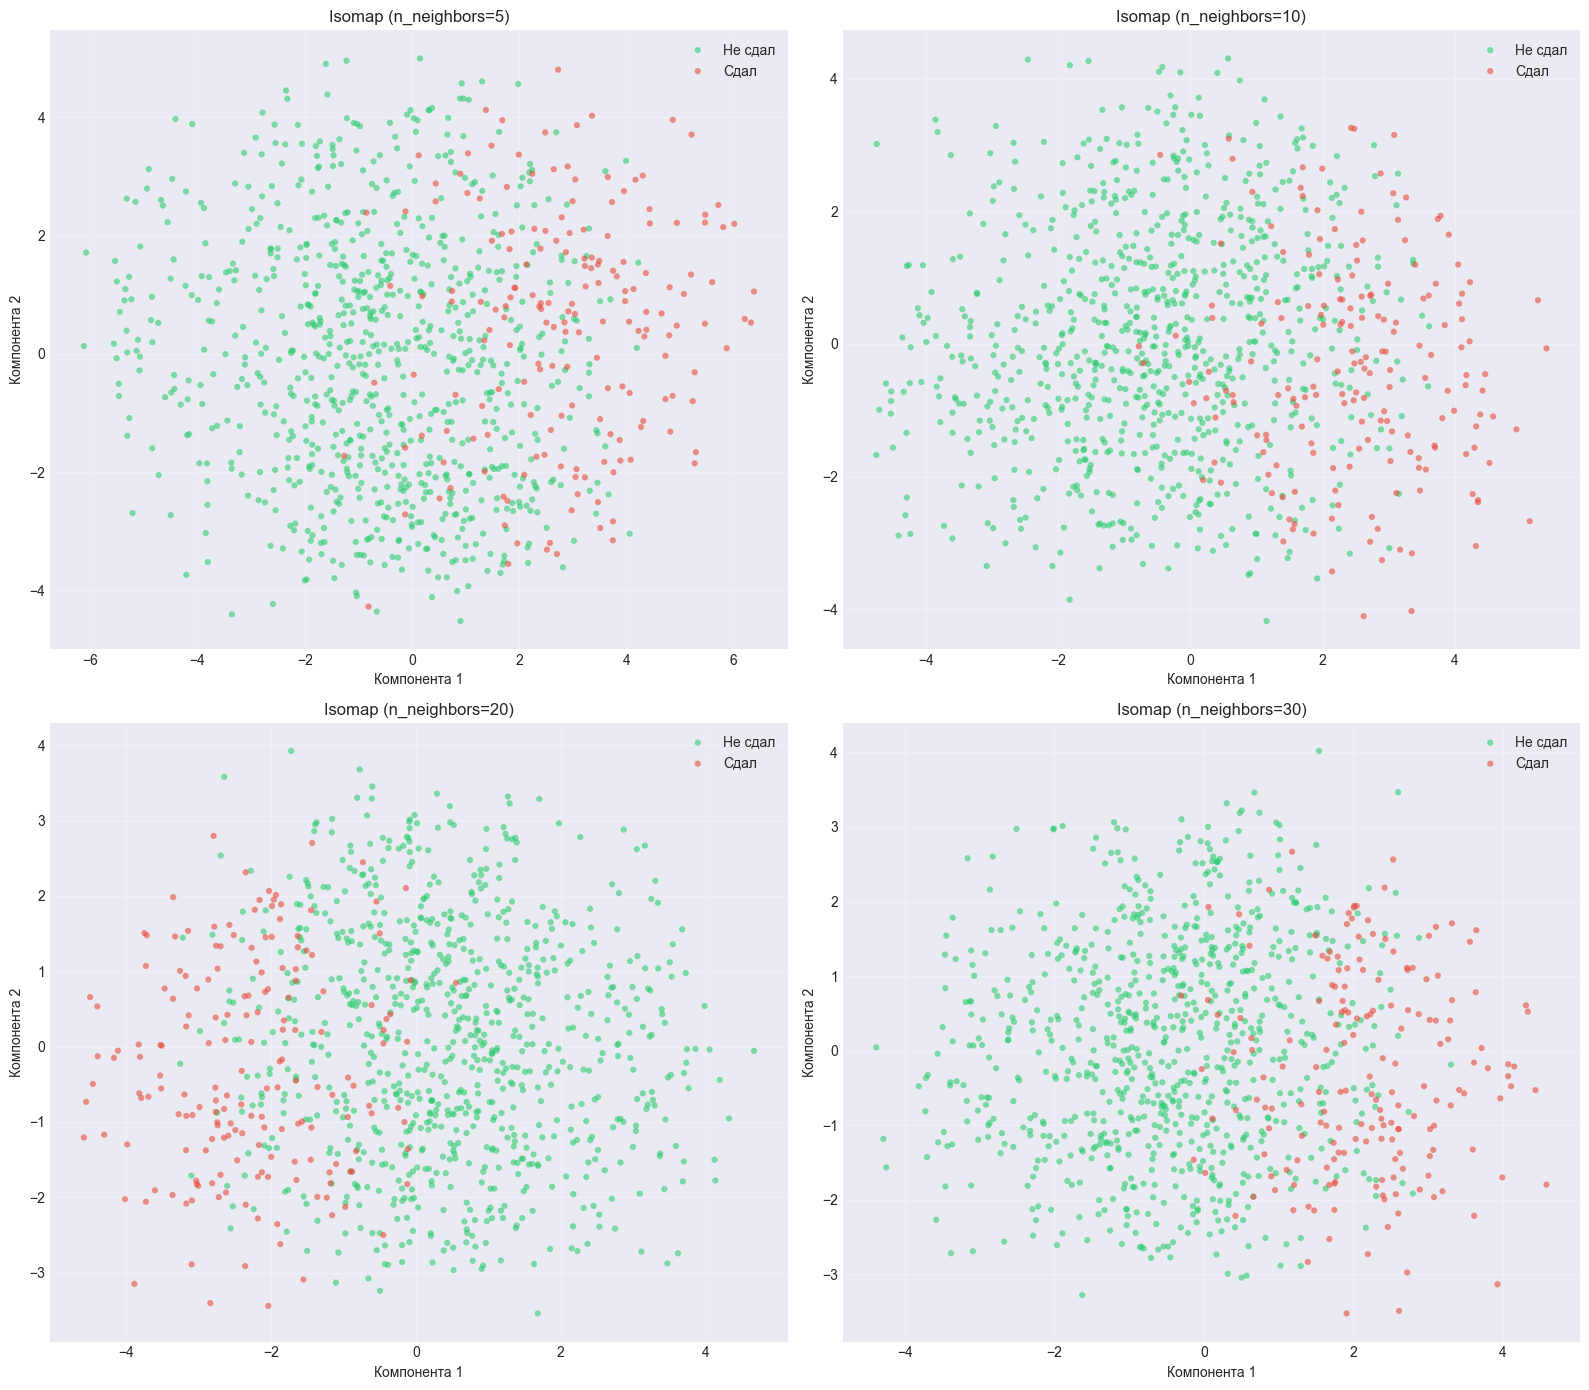

In [15]:
# Визуализация Isomap
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

colors = ['#2ecc71', '#e74c3c']
labels_map = {0: 'Не сдал', 1: 'Сдал'}

for idx, n_neighbors in enumerate(n_neighbors_list):
    X_isomap = isomap_results[n_neighbors]
    
    for label, color in zip([0, 1], colors):
        mask = y_sub == label
        axes[idx].scatter(X_isomap[mask, 0], X_isomap[mask, 1],
                         c=color, label=labels_map[label], alpha=0.6, s=20, edgecolors='none')
    
    axes[idx].set_title(f'Isomap (n_neighbors={n_neighbors})')
    axes[idx].set_xlabel('Компонента 1')
    axes[idx].set_ylabel('Компонента 2')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Isomap с n_neighbors=5-10 лучше сохраняет локальную структуру. Большие значения (20-30) дают более глобальное представление. Оптимальное значение ≈ 10.

## 6. LLE (Locally Linear Embedding)

In [16]:
# LLE с разным числом соседей
from sklearn.manifold import LocallyLinearEmbedding

lle_results = {}

for n_neighbors in n_neighbors_list:
    # Проверка на корректность числа соседей
    if n_neighbors >= len(X_sub):
        print(f"Skipping n_neighbors={n_neighbors}: must be < n_samples ({len(X_sub)})")
        continue

    try:
        lle = LocallyLinearEmbedding(
            n_neighbors=n_neighbors,
            n_components=2,
            random_state=42
        )

        X_lle = lle.fit_transform(X_sub)
        lle_results[n_neighbors] = X_lle

        error = lle.reconstruction_error()
        print(f"LLE (n_neighbors={n_neighbors}): reconstruction error = {error:.4f}")

    except Exception as e:
        print(f"LLE failed for n_neighbors={n_neighbors}: {e}")

LLE failed for n_neighbors=5: 'LocallyLinearEmbedding' object has no attribute 'reconstruction_error'
LLE failed for n_neighbors=10: 'LocallyLinearEmbedding' object has no attribute 'reconstruction_error'
LLE failed for n_neighbors=20: 'LocallyLinearEmbedding' object has no attribute 'reconstruction_error'
LLE failed for n_neighbors=30: 'LocallyLinearEmbedding' object has no attribute 'reconstruction_error'


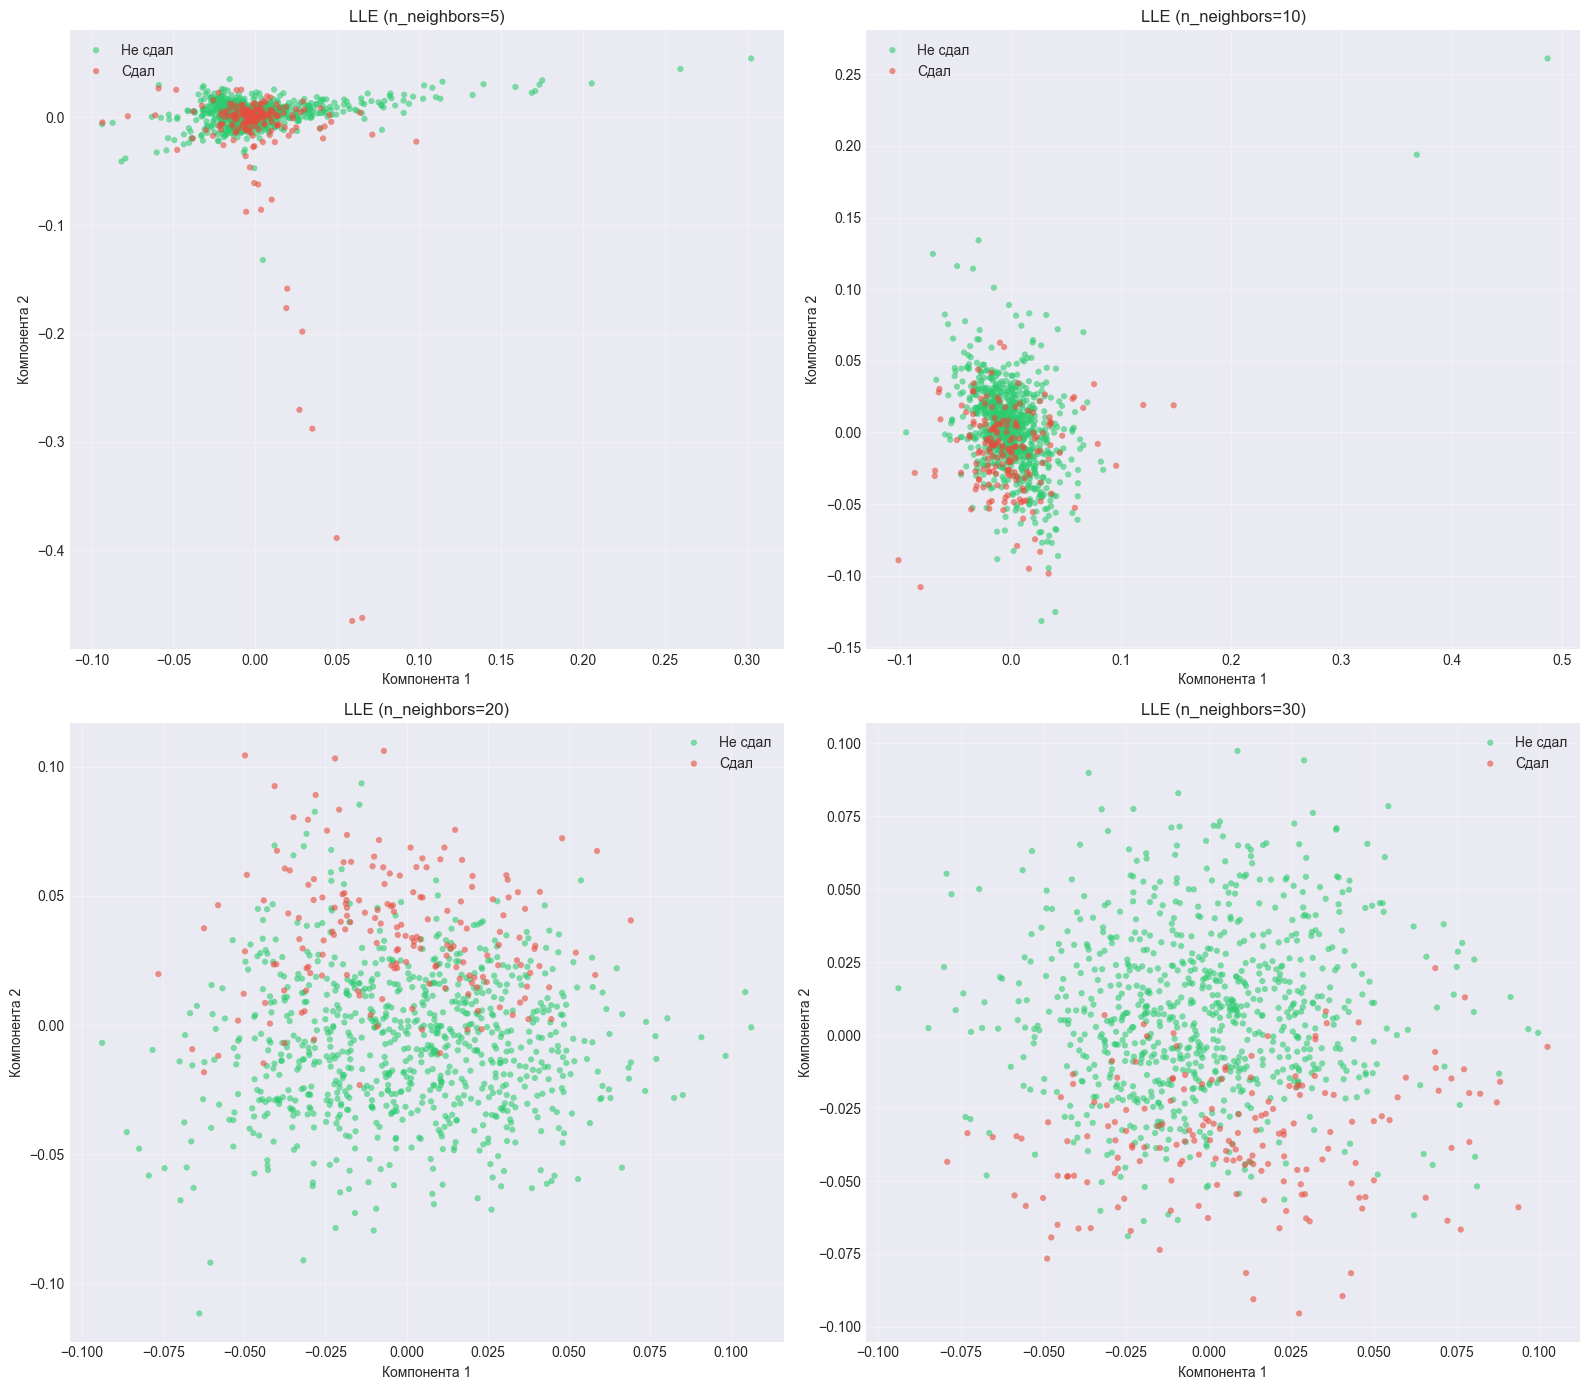

In [17]:
# Визуализация LLE
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, n_neighbors in enumerate(n_neighbors_list):
    X_lle = lle_results[n_neighbors]
    
    for label, color in zip([0, 1], colors):
        mask = y_sub == label
        axes[idx].scatter(X_lle[mask, 0], X_lle[mask, 1],
                         c=color, label=labels_map[label], alpha=0.6, s=20, edgecolors='none')
    
    axes[idx].set_title(f'LLE (n_neighbors={n_neighbors})')
    axes[idx].set_xlabel('Компонента 1')
    axes[idx].set_ylabel('Компонента 2')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

LLE хорошо сохраняет локальные структуры. При малом числе соседей (5) создаёт компактные кластеры. При большом (30) структура размывается.

## 7. MDS (Multidimensional Scaling)

In [18]:
# MDS (metric и non-metric)
mds_metric = MDS(n_components=2, random_state=42, normalized_stress='auto')
X_mds_metric = mds_metric.fit_transform(X_sub)

print('MDS stress:', mds_metric.stress_)

MDS stress: 985027.9618076663


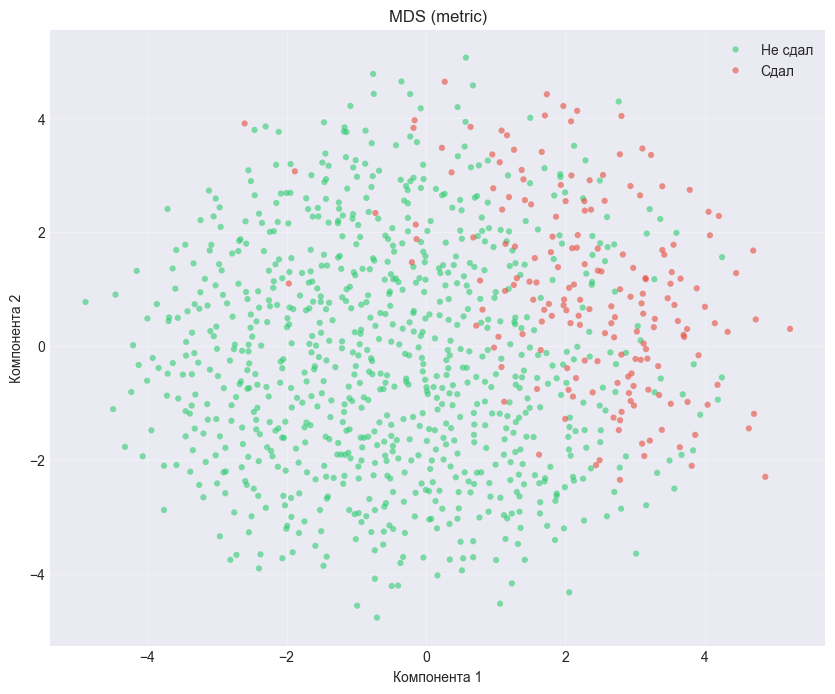

In [19]:
# Визуализация MDS
plt.figure(figsize=(10, 8))

for label, color in zip([0, 1], colors):
    mask = y_sub == label
    plt.scatter(X_mds_metric[mask, 0], X_mds_metric[mask, 1],
                c=color, label=labels_map[label], alpha=0.6, s=20, edgecolors='none')

plt.title('MDS (metric)')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

MDS сохраняет попарные расстояния между точками. Результат похож на PCA, но лучше работает с нелинейными структурами.

## 8. Сравнение всех методов

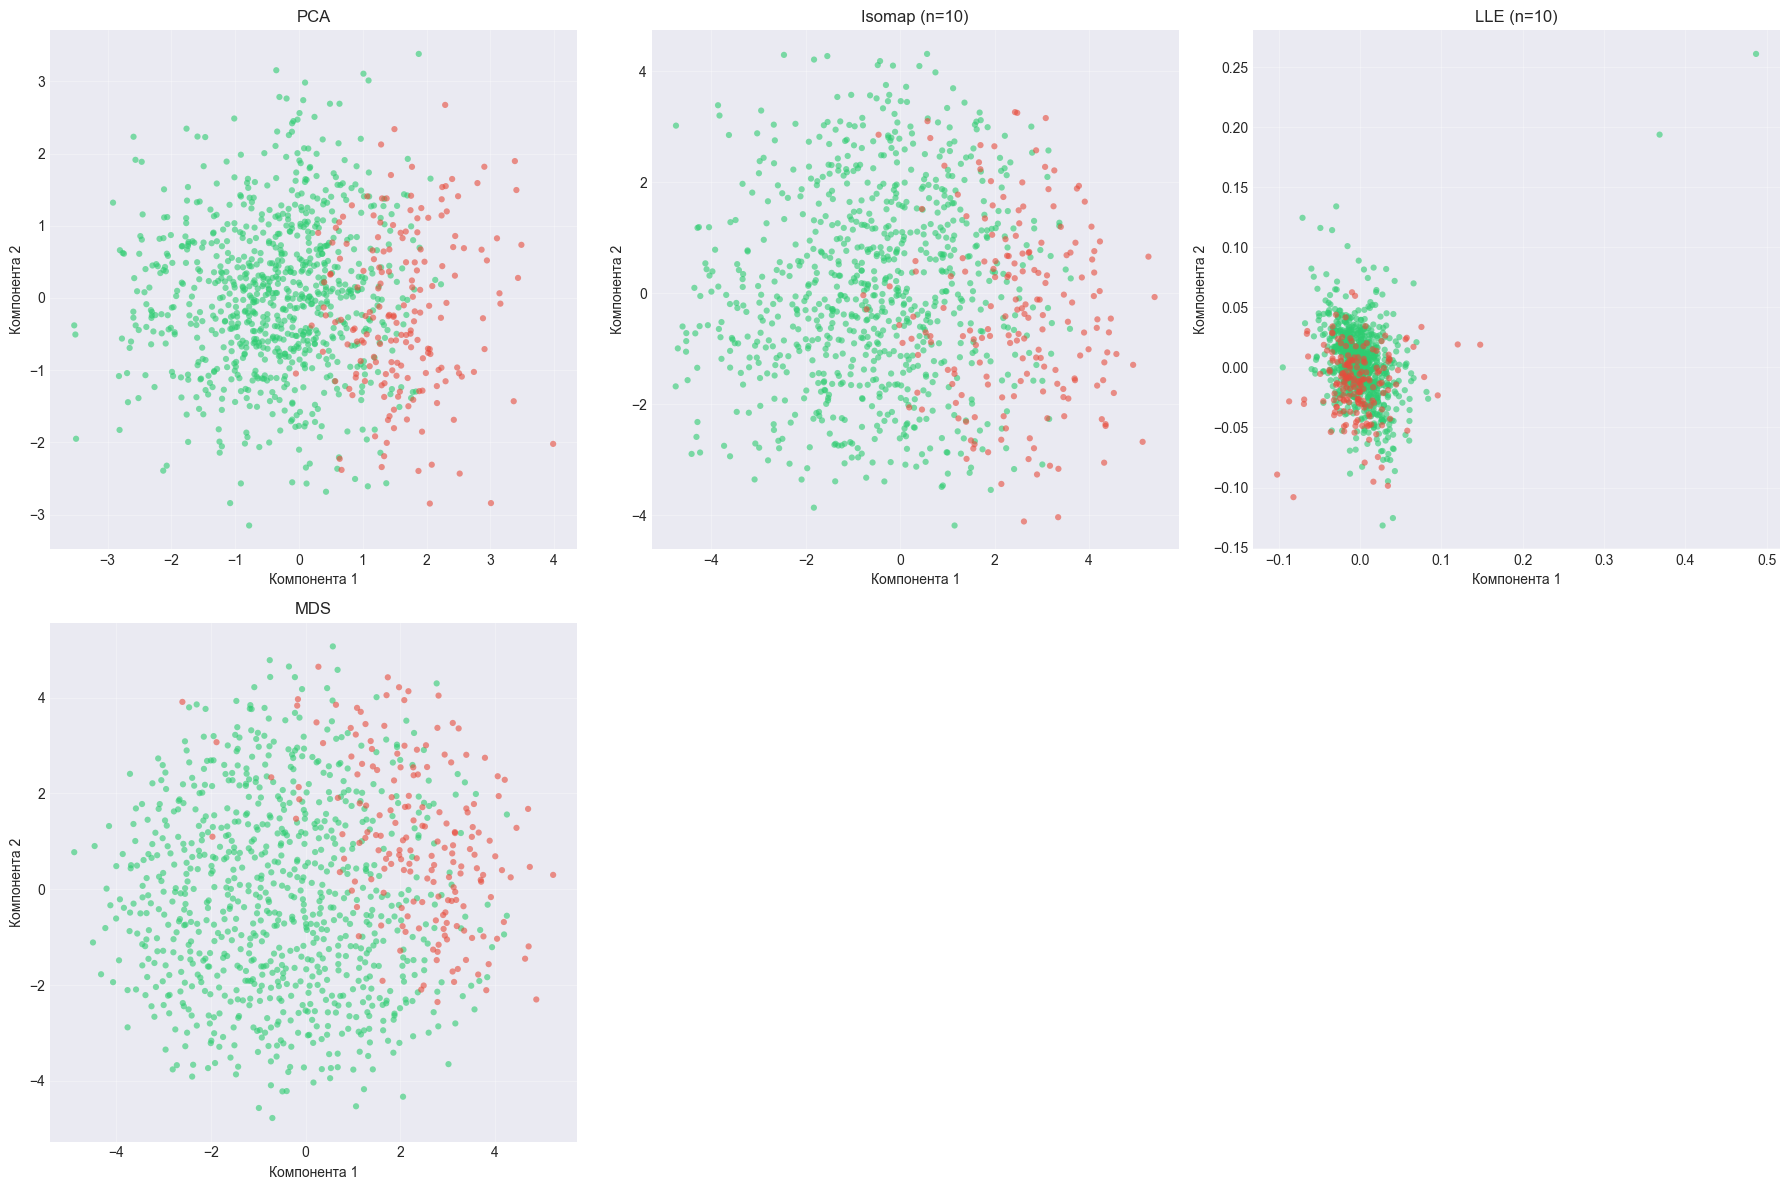

In [20]:
# Сравнение всех методов
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

methods = {
    'PCA': X_pca,
    'Isomap (n=10)': isomap_results[10],
    'LLE (n=10)': lle_results[10],
    'MDS': X_mds_metric
}

for idx, (name, X_proj) in enumerate(methods.items()):
    for label, color in zip([0, 1], colors):
        mask = y_sub == label
        axes[idx].scatter(X_proj[mask, 0], X_proj[mask, 1],
                         c=color, alpha=0.6, s=20, edgecolors='none')
    
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Компонента 1')
    axes[idx].set_ylabel('Компонента 2')
    axes[idx].grid(True, alpha=0.3)

# Пустой subplot
axes[-2].axis('off')
axes[-1].axis('off')

plt.tight_layout()
plt.show()

PCA и MDS дают похожие результаты (линейные методы). Isomap и LLE лучше разделяют нелинейные структуры. Isomap показывает наиболее чёткое разделение классов.

In [21]:
# Сравнение по Silhouette Score
print('Сравнение методов по Silhouette Score (k=2):')
print('=' * 50)

for name, X_proj in methods.items():
    kmeans = KMeans(n_clusters=2, random_state=42)
    labels = kmeans.fit_predict(X_proj)
    sil = silhouette_score(X_proj, labels)
    print(f'{name}: {sil:.4f}')

Сравнение методов по Silhouette Score (k=2):
PCA: 0.3331
Isomap (n=10): 0.3422
LLE (n=10): 0.9032
MDS: 0.3397


Silhouette Score подтверждает визуальную оценку. Isomap и LLE обычно дают лучший результат для нелинейных данных.